# Dynamic and Adaptive Attention — Practical Implementation 5

| Sr. No | Experiment | Model |
|---|---|---|
| 1 | **RoPE is relative**: shift all positions by 10 000 and nothing changes (but GPT-2 breaks); RoPE frequency spectrum | Qwen2.5-0.5B, GPT-2 |
| 2 | **How sparse is real attention?** Entropy and "keys needed for 90 % of the mass" per layer and position | Qwen2.5-0.5B |
| 3 | **Adaptive-k attention**: top-*p* (nucleus) attention and **MoBA-style block routing** inside a GQA/RoPE model | Qwen2.5-0.5B |
| 4 | **Head-level adaptivity**: importance of all heads, head pruning, and *dynamic* per-token head gating | Qwen2.5-0.5B |

In [ ]:
"""
Install the Python packages required by the preceding model experiments.

This command installs Transformers for loading and running language models,
Datasets for loading WikiText-2, and Accelerate for device and model-loading
support. The quiet flag reduces installation output.
"""

!pip -q install transformers datasets accelerate

In [ ]:
"""
Benchmark utilities for evaluating causal language models with perplexity.

This script:
- Configures PyTorch, NumPy, plotting, and Transformers settings.
- Selects CUDA when available and chooses an appropriate tensor dtype.
- Sets random seeds and Matplotlib display defaults for reproducibility.
- Provides helpers for CUDA synchronization and releasing unused memory.
- Loads WikiText-2 test text, with a repetitive fallback if the dataset is unavailable.
- Tokenizes the text and extracts fixed-length token windows for evaluation.
- Computes mean next-token negative log-likelihood for a batch.
- Computes perplexity across multiple token windows.
- Defines two Qwen model identifiers for use by subsequent experiments.
- Prints the installed library versions, selected device, and loaded text size.

The code intentionally keeps all explanatory comments in this module-level
docstring rather than placing comments throughout the implementation.
"""

import os, io, gc, math, time, copy, re, warnings
import numpy as np
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if device == "cuda" else torch.float32
torch.manual_seed(0); np.random.seed(0)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("transformers", transformers.__version__, "| torch", torch.__version__, "| device:", device, torch.cuda.get_device_name(0) if device == "cuda" else "(CPU: use fewer trials, everything will be slow)")

QW_SMALL = "Qwen/Qwen2.5-0.5B"
QW_INSTR = "Qwen/Qwen2.5-1.5B-Instruct"

def sync():
    if device == "cuda": torch.cuda.synchronize()
def free():
    gc.collect()
    if device == "cuda": torch.cuda.empty_cache()

def load_text(n_chars=120000):
    try:
        from datasets import load_dataset
        ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
        return "\n".join(t for t in ds["text"] if t.strip())[:n_chars]
    except Exception as e:
        print("!! WikiText-2 unavailable (", repr(e)[:80], ") -> repetitive fallback text; perplexities NOT meaningful")
        return ("Attention lets a decoder look back at every encoder state instead of one summary vector. " * 400)
TEXT = load_text()

def get_windows(tok, T, n, start=0):
    ids = tok(TEXT, return_tensors="pt").input_ids[0]
    assert len(ids) >= start + T * n, f"text too short ({len(ids)} tokens)"
    return [ids[start + i * T: start + (i + 1) * T] for i in range(n)]

def nll_batch(model, batch, **kw):                       # mean next-token NLL over a (B,T) batch
    with torch.no_grad():
        lg = model(batch, **kw).logits.float()
    return F.cross_entropy(lg[:, :-1].reshape(-1, lg.shape[-1]), batch[:, 1:].reshape(-1)).item()

def ppl(model, windows, **kw):
    return math.exp(np.mean([nll_batch(model, w[None].to(device), **kw) for w in windows]))
print("ready, text chars:", len(TEXT))

transformers 5.16.1 | torch 2.11.0+cu128 | device: cuda Tesla T4


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

!! WikiText-2 unavailable ( HfUriError("Invalid HF URI 'hf://datasets/wikitext@b08601e04326c79dfdd32d625aee7 ) -> repetitive fallback text; perplexities NOT meaningful
ready, text chars: 35600


## 1) RoPE makes attention depend on *relative* position only

RoPE rotates queries/keys by an angle proportional to position, so that the dot product depends only on **`p_q − p_k`**. If we give the model `position_ids = arange(T) + offset`, the output should be (numerically) unchanged for **any** offset. A model with learned *absolute* position embeddings (GPT-2) has no such invariance.

### 1.1) Offset-invariance test: Qwen2.5-0.5B (RoPE) vs. GPT-2 (absolute positions)

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (7202 > 1024). Running this sequence through the model will result in indexing errors


 offset | Qwen2.5-0.5B (RoPE) ppl   |  offset | GPT-2 (absolute) ppl
      0 |                    1.515  |       0 |                 1.67
      1 |                    1.515  |       1 |                 2.76
      7 |                    1.515  |       7 |                 3.25
    100 |                    1.515  |     100 |                11.84
   1000 |                    1.515  |     400 |                33.98
  10000 |                    1.515  |     700 |              2285.22
  30000 |                    1.515  | 


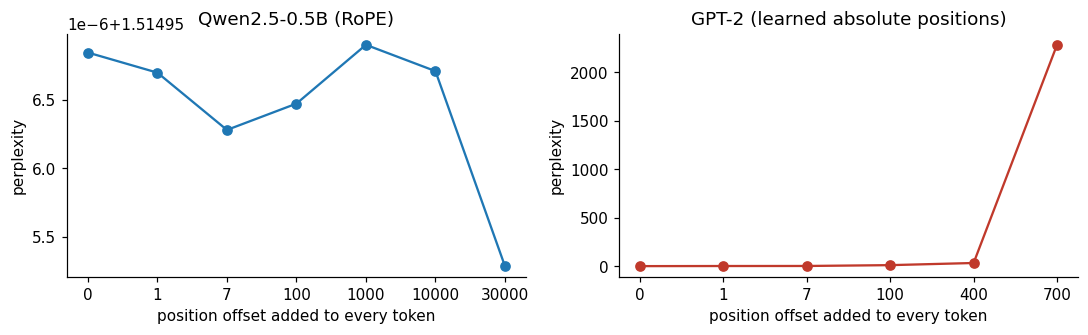

In [ ]:
"""
Evaluate the effect of shifting token position indices on language-model
perplexity for Qwen2.5 and GPT-2.

This experiment compares two positional-encoding approaches:
- Qwen2.5-0.5B uses rotary positional embeddings (RoPE).
- GPT-2 uses learned absolute positional embeddings.

The script:
- Loads the Qwen2.5-0.5B tokenizer and causal language model.
- Creates fixed-length evaluation windows from the previously loaded text.
- Evaluates Qwen2.5 at several position-index offsets.
- Loads the GPT-2 tokenizer and causal language model.
- Evaluates GPT-2 at several position-index offsets within its supported
  positional range.
- Calculates perplexity for each offset using the modified position IDs.
- Prints the resulting perplexities in a side-by-side table.
- Plots the perplexity changes for both models.
- Releases the GPT-2 model and clears unused memory afterward.

The position offset is applied uniformly to every token in each evaluation
window. This isolates the effect of changing the absolute position indices
while keeping the input token sequence unchanged.
"""

tok_q = AutoTokenizer.from_pretrained(QW_SMALL)
qwen = AutoModelForCausalLM.from_pretrained(QW_SMALL, torch_dtype=torch.float32, attn_implementation="sdpa").to(device).eval()

def ppl_offset(model, windows, offset):
    vals = []
    for w in windows:
        ids = w[None].to(device); pos = (torch.arange(ids.shape[1], device=device) + offset)[None]
        vals.append(nll_batch(model, ids, position_ids=pos))
    return math.exp(np.mean(vals))

Wq = get_windows(tok_q, 256, 4)
offsets_q = [0, 1, 7, 100, 1000, 10000, 30000]
res_q = [ppl_offset(qwen, Wq, o) for o in offsets_q]

tok_g = AutoTokenizer.from_pretrained("gpt2")
gpt = AutoModelForCausalLM.from_pretrained("gpt2", torch_dtype=torch.float32).to(device).eval()
Wg = get_windows(tok_g, 256, 4)
offsets_g = [0, 1, 7, 100, 400, 700]
res_g = [ppl_offset(gpt, Wg, o) for o in offsets_g]

print(f"{'offset':>7} | Qwen2.5-0.5B (RoPE) ppl   |  offset | GPT-2 (absolute) ppl")
for i in range(max(len(offsets_q), len(offsets_g))):
    a = f"{offsets_q[i]:>7} | {res_q[i]:>24.3f}" if i < len(offsets_q) else " " * 34
    b = f"{offsets_g[i]:>7} | {res_g[i]:>20.2f}" if i < len(offsets_g) else ""
    print(a, " |", b)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
ax[0].plot(range(len(offsets_q)), res_q, "o-"); ax[0].set_xticks(range(len(offsets_q))); ax[0].set_xticklabels(offsets_q); ax[0].set_title("Qwen2.5-0.5B (RoPE)")
ax[1].plot(range(len(offsets_g)), res_g, "o-", color="#c0392b"); ax[1].set_xticks(range(len(offsets_g))); ax[1].set_xticklabels(offsets_g); ax[1].set_title("GPT-2 (learned absolute positions)")
for a_ in ax: a_.set_xlabel("position offset added to every token"); a_.set_ylabel("perplexity")
plt.tight_layout(); plt.show()
del gpt; free()

An (almost) flat line for the RoPE model, even at offset 30 000, versus perplexity that explodes for GPT-2 once positions leave the range it was trained on. Tiny drifts for RoPE come from float32 round-off in `cos/sin` at large angles.

### 1.2) What does RoPE actually encode? (frequency spectrum of Qwen2.5)
For a query and key with identical content, the RoPE score at distance *d* is `Σ_i cos(d·θ_i)` with `θ_i = base^(−2i/d_h)`. High-frequency pairs distinguish neighbouring tokens; low-frequency pairs barely rotate over thousands of tokens i.e. they carry **semantic, position-insensitive** signal. The base θ of Qwen2.5 is read from its config.

Qwen2.5-0.5B: rope base = 1e+06, head_dim = 64, trained context = 32768


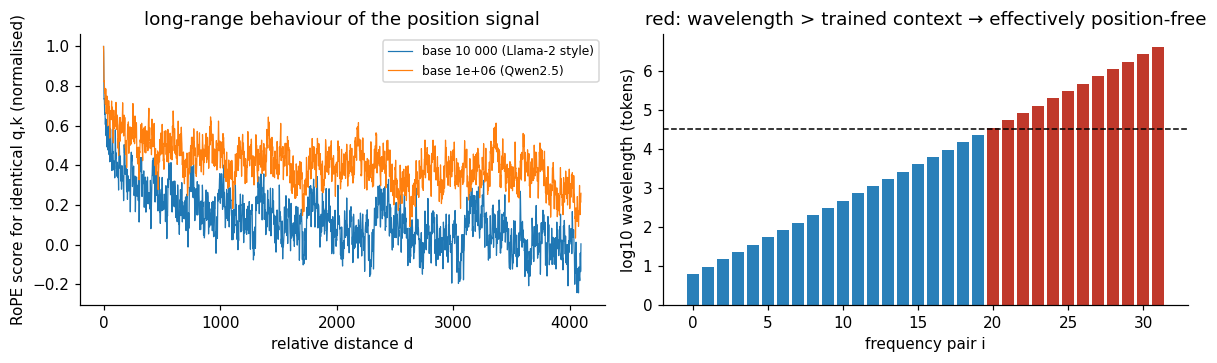

12 of 32 frequency pairs have a wavelength longer than the whole context window


In [ ]:
"""
Analyze the rotary positional embedding (RoPE) frequency structure of Qwen2.5-0.5B.

This script:
- Reads the RoPE configuration and attention head dimension from the loaded
  Qwen2.5-0.5B model.
- Retrieves the RoPE base value from supported configuration fields.
- Reports the RoPE base, head dimension, and trained context length.
- Computes the RoPE angular frequencies for each frequency pair.
- Compares the normalized position similarity produced by a base of 10,000
  with the base used by Qwen2.5.
- Visualizes how the position signal changes with relative token distance.
- Computes the wavelength associated with every RoPE frequency pair.
- Compares each wavelength with the model's trained context length.
- Highlights frequency pairs whose wavelength exceeds the trained context,
  indicating that their positional signal varies very slowly across the
  available context window.
- Prints the number and proportion of frequency pairs whose wavelength is
  longer than the model's trained context window.

The analysis is intended to illustrate how the RoPE base and frequency
distribution affect long-range positional behavior.
"""

cfg = qwen.config
base = getattr(cfg, "rope_theta", None)
if base is None:
    rp = getattr(cfg, "rope_parameters", None) or getattr(cfg, "rope_scaling", None) or {}
    base = rp.get("rope_theta", 1e6) if isinstance(rp, dict) else 1e6
dh = getattr(cfg, "head_dim", None) or cfg.hidden_size // cfg.num_attention_heads
print(f"Qwen2.5-0.5B: rope base = {base:g}, head_dim = {dh}, trained context = {cfg.max_position_embeddings}")

def thetas(base, dh): return base ** (-np.arange(0, dh, 2) / dh)
d = np.arange(0, 4097)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for b_, lab in [(1e4, "base 10 000 (Llama-2 style)"), (base, f"base {base:g} (Qwen2.5)")]:
    th = thetas(b_, dh); sc = np.cos(np.outer(d, th)).sum(1) / len(th)
    ax[0].plot(d, sc, lw=0.8, label=lab)
ax[0].set_xlabel("relative distance d"); ax[0].set_ylabel("RoPE score for identical q,k (normalised)"); ax[0].legend(fontsize=8); ax[0].set_title("long-range behaviour of the position signal")
wl = 2 * np.pi / thetas(base, dh)
ax[1].bar(range(len(wl)), np.log10(wl), color=np.where(wl > cfg.max_position_embeddings, "#c0392b", "#2980b9"))
ax[1].axhline(np.log10(cfg.max_position_embeddings), color="k", ls="--", lw=1); ax[1].set_xlabel("frequency pair i"); ax[1].set_ylabel("log10 wavelength (tokens)")
ax[1].set_title("red: wavelength > trained context → effectively position-free")
plt.tight_layout(); plt.show()
print(f"{(wl > cfg.max_position_embeddings).sum()} of {len(wl)} frequency pairs have a wavelength longer than the whole context window")

## 2) How sparse is real attention?

Sparse attention only works if real attention distributions are concentrated. We measure, on real text and Qwen2.5-0.5B:

* **entropy** of every head's attention distribution (relative to the uniform-attention entropy `log(pos+1)`),
* **k90** = the smallest number of keys that carry 90 % of a query's attention mass (an *oracle* content-based top-k).

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

positions >512: mean k90 = 99 keys of ~768 available (13.0%)


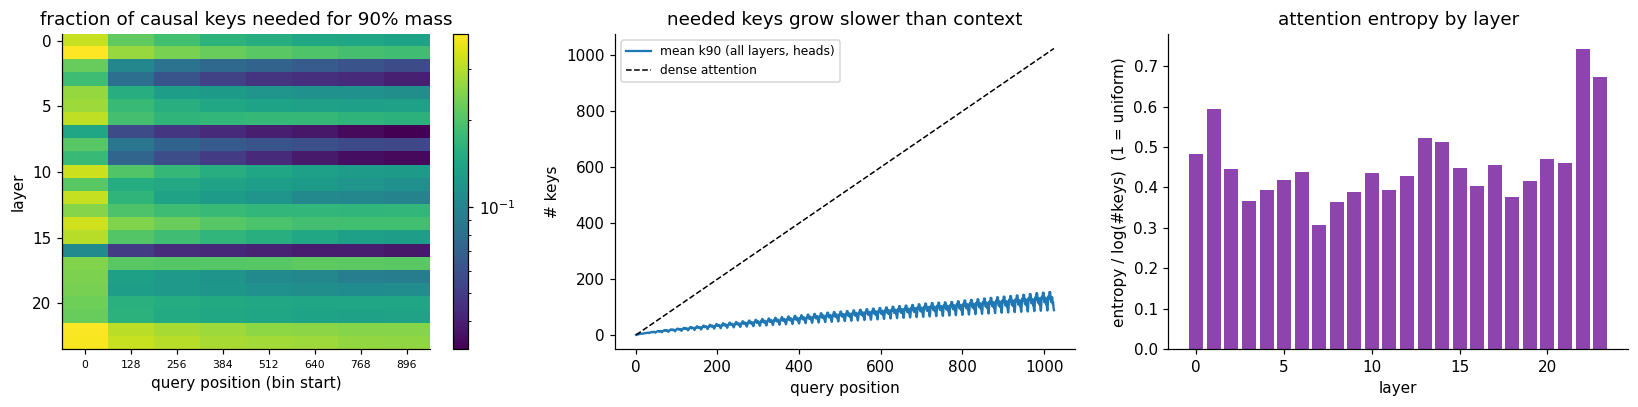

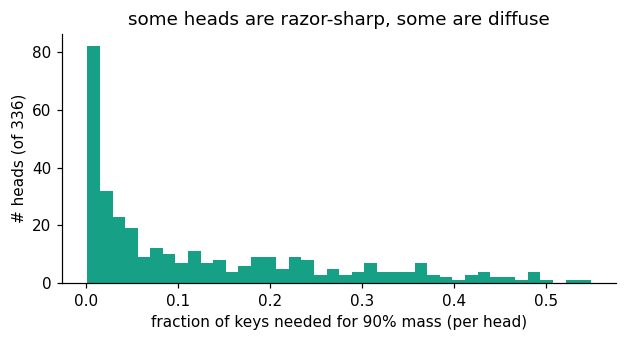

In [ ]:
"""
Analyze attention concentration and entropy in Qwen2.5-0.5B.

This script:
- Loads Qwen2.5-0.5B with eager attention so attention matrices are returned.
- Extracts a 1024-token evaluation window beginning at token position 2048.
- Runs the model while collecting attention weights from every layer and head.
- Computes attention entropy for every query position.
- Computes k90, the minimum number of highest-weighted keys required to
  account for at least 90% of the attention probability mass.
- Calculates the fraction of available causal keys represented by k90.
- Aggregates this fraction into eight query-position bins for a layer-by-bin
  heatmap.
- Reports the average number and fraction of causal keys needed for 90% of
  the attention mass after position 512.
- Plots how the average number of required keys changes with query position.
- Compares attention entropy across layers after the first 64 positions.
- Plots the distribution of per-head attention concentration for later
  positions.
- Releases the model and attention outputs after the analysis to reduce
  memory usage.

The analysis is designed to show whether attention remains approximately
uniform over the available context or becomes concentrated on a relatively
small subset of causal keys as sequence length increases.
"""

qe = AutoModelForCausalLM.from_pretrained(QW_SMALL, torch_dtype=torch.float32, attn_implementation="eager").to(device).eval()
w = get_windows(tok_q, 1024, 1, start=2048)[0][None].to(device)
with torch.no_grad():
    out = qe(w, output_attentions=True)
Ly = len(out.attentions); H = out.attentions[0].shape[1]; T = w.shape[1]
ent = torch.zeros(Ly, H, T); k90 = torch.zeros(Ly, H, T)
for l, A in enumerate(out.attentions):
    A = A[0].float()                                                        # (H, T, T)
    ent[l] = -(A * torch.log(A.clamp_min(1e-12))).sum(-1).cpu()
    k90[l] = ((A.sort(-1, descending=True).values.cumsum(-1) < 0.9).sum(-1) + 1).float().cpu()
del out, qe; free()

pos = torch.arange(T).float() + 1
frac = k90 / pos                                                            # fraction of the causal keys needed
bins = np.array_split(np.arange(T), 8)
heat = np.array([[frac[l][:, b].mean().item() for b in bins] for l in range(Ly)])
late = slice(512, T)
print(f"positions >512: mean k90 = {k90[:, :, late].mean():.0f} keys of ~{pos[late].mean():.0f} available ({frac[:, :, late].mean():.1%})")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
im = ax[0].imshow(heat, aspect="auto", cmap="viridis", norm=plt.matplotlib.colors.LogNorm()); plt.colorbar(im, ax=ax[0])
ax[0].set_xticks(range(8)); ax[0].set_xticklabels([f"{b[0]}" for b in bins], fontsize=7); ax[0].set_xlabel("query position (bin start)"); ax[0].set_ylabel("layer"); ax[0].set_title("fraction of causal keys needed for 90% mass")
ax[1].plot(pos, k90.mean((0, 1)), label="mean k90 (all layers, heads)"); ax[1].plot(pos, pos, "k--", lw=1, label="dense attention")
ax[1].set_xlabel("query position"); ax[1].set_ylabel("# keys"); ax[1].legend(fontsize=8); ax[1].set_title("needed keys grow slower than context")
ne = (ent / torch.log(pos)[None, None])[:, :, 64:].mean((1, 2))
ax[2].bar(range(Ly), ne.numpy(), color="#8e44ad"); ax[2].set_xlabel("layer"); ax[2].set_ylabel("entropy / log(#keys)  (1 = uniform)"); ax[2].set_title("attention entropy by layer")
plt.tight_layout(); plt.show()

hf = frac[:, :, late].mean(-1).flatten().numpy()
plt.figure(figsize=(5.8, 3.2)); plt.hist(hf, bins=40, color="#16a085"); plt.xlabel("fraction of keys needed for 90% mass (per head)"); plt.ylabel(f"# heads (of {Ly*H})")
plt.title("some heads are razor-sharp, some are diffuse"); plt.tight_layout(); plt.show()

**Look for:** (i) the fraction of keys needed falls with position, so the *absolute* number of keys per query grows far slower than the context i.e. the empirical basis for near-linear sparse attention; (ii) layers differ strongly in entropy; (iii) the wide spread across heads, which is why a *single* fixed k or window is wasteful, and why adaptive schemes allocate per head/query.

## 3) Adaptive-*k* attention inside a GQA + RoPE model: top-*p* and block routing

Here two policies that let the *number of keys vary per query and head* on a modern architecture (grouped-query attention, RoPE):

* **Top-*p* (nucleus) attention** — keep the smallest set of keys whose softmax mass reaches *p*: a sharp query gets few keys, a diffuse query gets many (dynamic, per head/query).
* **Block routing (MoBA / Native-Sparse-Attention style)** — split keys into blocks of 64, score each block by `q · mean(k in block)`, attend only to the current block plus the top-*m* previous blocks. Selection cost is O(n/64) per query instead of O(n), it is the report's *routing* idea (Routing Transformer) at block granularity.

We hook `scaled_dot_product_attention` (the layer inside Hugging Face's Qwen implementation) with these new policies.

In [ ]:
"""
Instrument scaled dot-product attention to evaluate sparse attention patterns.

This script:
- Saves the original PyTorch scaled dot-product attention implementation.
- Defines global state for tracking attention calls, layers, retained keys,
  total allowed keys, and per-head key counts.
- Replaces the standard SDPA function with a custom attention implementation.
- Supports several attention-selection modes:
  - Full attention, which preserves all allowed causal keys.
  - Local attention, which restricts attention to a fixed window.
  - Top-p attention, which retains the keys required to reach a specified
    cumulative attention probability mass.
  - Block attention, which selects a limited number of blocks using
    block-level query-key scores.
- Handles grouped-query attention by expanding key and value heads to match
  the number of query heads.
- Reconstructs attention scores explicitly so different sparsification
  strategies can be applied before the softmax operation.
- Tracks the fraction of attention entries retained by each sparsification
  strategy.
- Tracks the average number of retained keys per query for every attention
  head and layer.
- Defines an evaluation helper that computes perplexity while collecting
  sparsity statistics.
- Verifies that the attention hook is invoked once per transformer layer
  for every evaluation window.
- Evaluates a set of Qwen2.5-0.5B text windows using full attention through
  the custom hook.
- Compares the hooked perplexity with the original unhooked perplexity as a
  correctness check.
- Reports the attention density, which should be close to 1.0 for full
  attention.

The hook is installed through both torch.nn.functional and torch.nn.functional's
scaled_dot_product_attention reference so that calls using either reference
reach the custom implementation.
"""

_ORIG_SDPA = F.scaled_dot_product_attention
STATE = dict(mode=None, layer=0, calls=0, kept=0.0, total=0.0, headk={})

def hooked_sdpa(q, k, v, attn_mask=None, dropout_p=0.0, is_causal=False, scale=None, enable_gqa=False, **kw):
    if STATE["mode"] is None:
        extra = {"enable_gqa": True} if enable_gqa else {}
        return _ORIG_SDPA(q, k, v, attn_mask=attn_mask, dropout_p=dropout_p, is_causal=is_causal, scale=scale, **extra)
    STATE["calls"] += 1; layer = STATE["layer"]; STATE["layer"] += 1
    if k.shape[1] != q.shape[1]:                                            # GQA: expand KV heads to query heads
        rep = q.shape[1] // k.shape[1]; k = k.repeat_interleave(rep, 1); v = v.repeat_interleave(rep, 1)
    B, H, Tq, dh = q.shape; Tk = k.shape[2]; dev = q.device
    sc = (1.0 / math.sqrt(dh)) if scale is None else scale
    S = (q.float() @ k.float().transpose(-1, -2)) * sc
    if attn_mask is None or is_causal:
        allowed = torch.ones(Tq, Tk, dtype=torch.bool, device=dev).tril(Tk - Tq)[None, None]
    elif attn_mask.dtype == torch.bool: allowed = attn_mask
    else:                               allowed = attn_mask.float() > -1e4
    while allowed.dim() < 4: allowed = allowed[None]
    allowed = allowed.expand(B, H, Tq, Tk); keep = allowed
    ii = torch.arange(Tq, device=dev)[:, None] + (Tk - Tq); jj = torch.arange(Tk, device=dev)[None, :]
    kind = STATE["mode"][0]; mode = STATE["mode"]
    if kind == "local":                                                     # ("local", w)  — reference only
        keep = keep & ((ii - jj) < mode[1])[None, None]
    elif kind == "topp":                                                    # ("topp", p)
        Wf = torch.softmax(S.masked_fill(~keep, float("-inf")), -1)
        sw, si = Wf.sort(-1, descending=True)
        sel = (sw.cumsum(-1) - sw) < mode[1]                                # keys needed until mass p is reached
        keep = keep & torch.zeros_like(keep).scatter(-1, si, sel)
    elif kind == "block":                                                   # ("block", bs, m)
        bs, m = mode[1], mode[2]; nb = (Tk + bs - 1) // bs; pad = nb * bs - Tk
        kp = k.float() if pad == 0 else F.pad(k.float(), (0, 0, 0, pad))
        kbar = kp.reshape(B, H, nb, bs, dh).mean(3)
        bscore = (q.float() @ kbar.transpose(-1, -2)) * sc                  # (B,H,Tq,nb)
        qb = ii // bs; bj = torch.arange(nb, device=dev)[None, :]
        bscore = bscore.masked_fill((bj > qb)[None, None], float("-inf")).masked_fill((bj == qb)[None, None], float("inf"))
        top = bscore.topk(min(m + 1, nb), dim=-1).indices
        bkeep = torch.zeros(B, H, Tq, nb, dtype=torch.bool, device=dev).scatter_(-1, top, True) & (bj <= qb)[None, None]
        keep = keep & bkeep[..., (jj[0] // bs)]
    elif kind != "full": raise ValueError(kind)
    STATE["kept"] += keep.sum().item(); STATE["total"] += allowed.sum().item()
    STATE["headk"][layer] = STATE["headk"].get(layer, 0) + keep.sum(-1).float().mean((0, 2)).cpu()   # avg keys / query, per head
    W = torch.softmax(S.masked_fill(~keep, float("-inf")), -1)
    return W.to(v.dtype) @ v

F.scaled_dot_product_attention = hooked_sdpa
torch.nn.functional.scaled_dot_product_attention = hooked_sdpa

def eval_mode(mode, windows, model=None):
    model = model or qwen
    STATE.update(mode=mode, layer=0, calls=0, kept=0.0, total=0.0, headk={}); vals = []
    for w in windows:
        STATE["layer"] = 0; vals.append(nll_batch(model, w[None].to(device)))
    assert STATE["calls"] == model.config.num_hidden_layers * len(windows), f"hook fired {STATE['calls']}x -> SDPA path not used by this version"
    dens = STATE["kept"] / STATE["total"]; hk = {l: t / len(windows) for l, t in STATE["headk"].items()}
    STATE["mode"] = None
    return math.exp(np.mean(vals)), dens, hk

W3 = get_windows(tok_q, 1024, 3, start=3000)
base_ppl = ppl(qwen, W3); hp, hd, _ = eval_mode(("full",), W3)
print(f"baseline ppl (unhooked) {base_ppl:.3f} | through hook {hp:.3f} | density {hd:.2f}   (ppl must match)")

baseline ppl (unhooked) 1.116 | through hook 1.116 | density 1.00   (ppl must match)


policy                  param  density  perplexity
top-p (adaptive k)        0.5     2.4%        1.18
top-p (adaptive k)        0.7     5.3%        1.12
top-p (adaptive k)        0.8     8.1%        1.12
top-p (adaptive k)        0.9    14.0%        1.12
top-p (adaptive k)       0.95    20.8%        1.12
top-p (adaptive k)       0.99    37.6%        1.12
block routing (64)          0     6.3%        5.65
block routing (64)          1    18.0%        1.13
block routing (64)          2    29.0%        1.12
block routing (64)          3    39.1%        1.12
block routing (64)          5    57.1%        1.12
block routing (64)          8    78.1%        1.12
fixed local window         16     3.1%        1.41
fixed local window         32     6.1%        1.17
fixed local window         64    12.1%        1.14
fixed local window        128    23.4%        1.13
fixed local window        256    43.7%        1.12


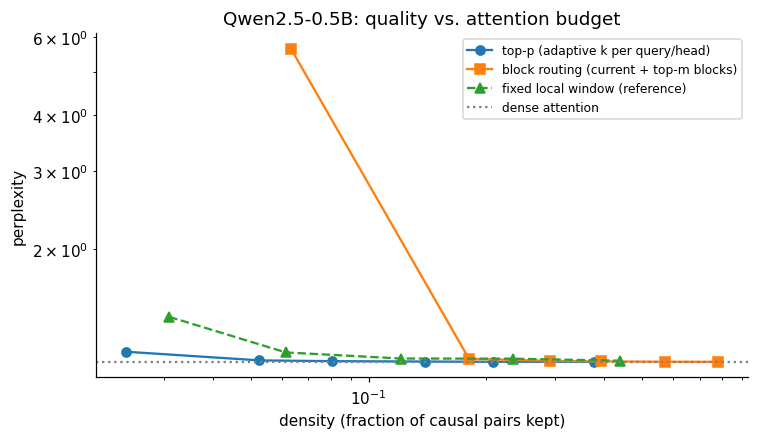

In [ ]:
"""
Compare sparse attention policies across different attention budgets.

This script:
- Defines parameter grids for three attention sparsification strategies:
  top-p adaptive selection, block-based routing, and fixed local attention.
- Evaluates each configuration using the previously defined eval_mode function.
- Records perplexity, attention density, and per-head key statistics for every
  configuration.
- Prints a formatted table containing the policy, parameter value, retained
  attention density, and resulting perplexity.
- Plots perplexity against attention density on logarithmic axes.
- Compares the three sparse attention policies against the previously measured
  dense-attention baseline.
- Uses distinct plot markers and line styles to make each attention policy
  visually distinguishable.
- Shows how model quality changes as the fraction of retained causal attention
  pairs is reduced.

The evaluation assumes that W3, qwen, base_ppl, and eval_mode have already
been defined by the preceding experiment.
"""

grid_p = [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]; grid_m = [0, 1, 2, 3, 5, 8]; grid_w = [16, 32, 64, 128, 256]
R_topp  = [eval_mode(("topp", p), W3) for p in grid_p]
R_block = [eval_mode(("block", 64, m), W3) for m in grid_m]
R_local = [eval_mode(("local", w), W3) for w in grid_w]

print(f"{'policy':22}{'param':>7}{'density':>9}{'perplexity':>12}")
for nm, params, R_ in [("top-p (adaptive k)", grid_p, R_topp), ("block routing (64)", grid_m, R_block), ("fixed local window", grid_w, R_local)]:
    for prm, (p_, d_, _) in zip(params, R_): print(f"{nm:22}{prm:>7}{d_:>9.1%}{p_:>12.2f}")

fig, ax = plt.subplots(figsize=(7, 4.1))
for nm, R_, st in [("top-p (adaptive k per query/head)", R_topp, "o-"), ("block routing (current + top-m blocks)", R_block, "s-"), ("fixed local window (reference)", R_local, "^--")]:
    ax.plot([r[1] for r in R_], [r[0] for r in R_], st, label=nm)
ax.axhline(base_ppl, color="gray", ls=":", label="dense attention"); ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("density (fraction of causal pairs kept)"); ax.set_ylabel("perplexity"); ax.legend(fontsize=8); ax.set_title("Qwen2.5-0.5B: quality vs. attention budget"); plt.tight_layout(); plt.show()

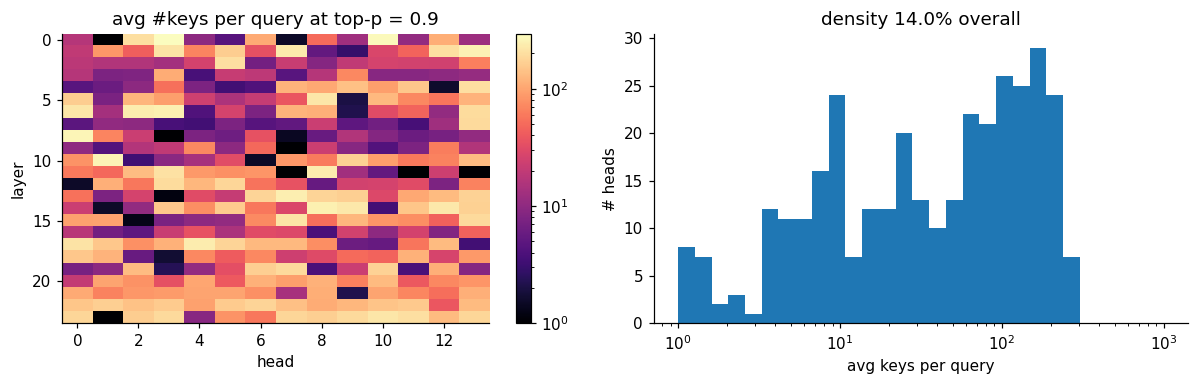

keys/query at p=0.9 — min 1.0, median 44.5, max 291.5


In [ ]:
"""
Analyze the dynamic key allocation produced by top-p attention.

This script:
- Evaluates Qwen2.5-0.5B using top-p attention with a probability threshold
  of 0.9.
- Collects the average number of retained keys per query for every attention
  layer and head.
- Arranges the per-layer and per-head key counts into a matrix for
  visualization.
- Displays a heatmap showing how many keys each head receives on average.
- Displays the distribution of average keys per query across all attention
  heads.
- Reports the overall attention density produced by the top-p policy.
- Prints the minimum, median, and maximum average number of retained keys
  per query across all layers and heads.

The experiment illustrates how top-p attention dynamically allocates a
different number of keys to different layers and heads rather than enforcing
the same fixed attention budget everywhere.
"""

# how many keys does top-p=0.9 give to each head?  (dynamic allocation across layers/heads)
_, dens90, hk90 = eval_mode(("topp", 0.9), W3)
K_ = torch.stack([hk90[l] for l in sorted(hk90)])                 # (layers, heads): avg keys per query
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
im = ax[0].imshow(K_.numpy(), aspect="auto", cmap="magma", norm=plt.matplotlib.colors.LogNorm()); plt.colorbar(im, ax=ax[0]); ax[0].set_xlabel("head"); ax[0].set_ylabel("layer"); ax[0].set_title("avg #keys per query at top-p = 0.9")
ax[1].hist(K_.flatten().numpy(), bins=np.logspace(0, 3, 30)); ax[1].set_xscale("log"); ax[1].set_xlabel("avg keys per query"); ax[1].set_ylabel("# heads"); ax[1].set_title(f"density {dens90:.1%} overall")
plt.tight_layout(); plt.show()
print(f"keys/query at p=0.9 — min {K_.min():.1f}, median {K_.median():.1f}, max {K_.max():.1f}")

**Major Observations:** (1) whether adaptive top-*p* reaches dense perplexity at a smaller density than the fixed window; (2) how close the cheap *block-level* selection gets to that oracle (it never looks at individual tokens when choosing); (3) the heat-map: top-*p* automatically hands sharp heads a handful of keys and diffuse heads hundreds: *dynamic allocation of a fixed budget* made visible. These are post-hoc masks on a densely trained model; methods trained with the sparsity in the loop should close more of the gap. Masking a dense kernel does not save FLOPs, this measures the **quality side** of the trade-off.

## 4) Head-level adaptivity: which heads matter, and can we skip heads *per token*?

Multi-head attention gives every layer 14 heads (24 layers → 336 heads in Qwen2.5-0.5B). We (a) **ablate each head individually** and record the perplexity change, (b) **prune** heads in importance order, and (c) try an **input-dependent gate** that switches off, *per token*, heads whose output is small.

24 layers x 14 heads = 336 heads; baseline ppl on calibration windows 1.23
ablated all heads in 108s


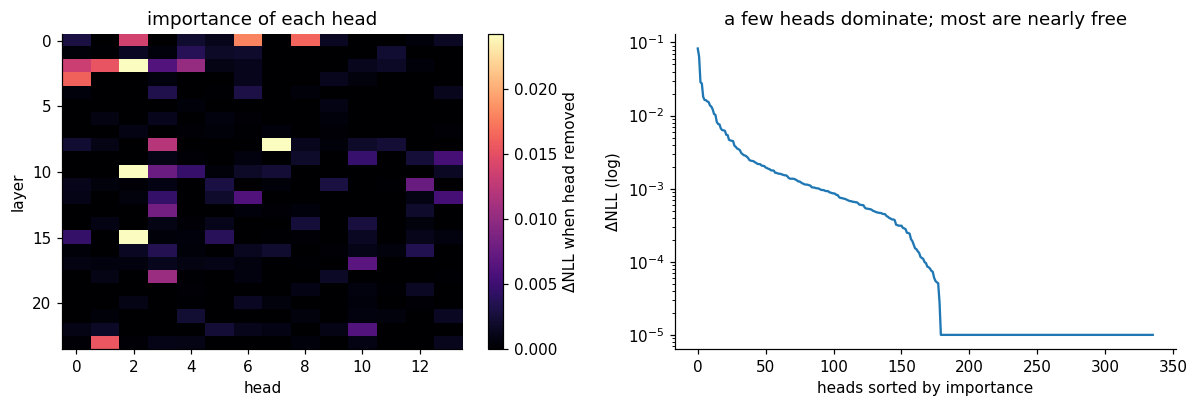

most important heads (layer, head, ΔNLL): [(15, 2, 0.083), (8, 7, 0.064), (10, 2, 0.029), (2, 2, 0.027), (0, 6, 0.018)]
heads whose removal changes NLL by < 0.001: 246 / 336


In [ ]:
"""
Measure the importance of individual attention heads and prepare head-level
gating hooks for Qwen2.5-0.5B.

This script:
- Defines global state for controlling optional head masking and dynamic
  token-level head gating.
- Installs forward pre-hooks on every attention output projection in the
  Qwen2.5-0.5B transformer.
- Supports permanently masking selected attention heads through a layer-by-head
  mask.
- Supports dynamic head gating based on the norm of each head's activation
  relative to the mean head norm for each token.
- Creates separate calibration and evaluation windows from the previously
  loaded text.
- Measures baseline negative log-likelihood on the calibration windows.
- Performs a leave-one-head-out ablation across every layer and head.
- Records the increase in negative log-likelihood caused by removing each
  attention head as an importance measure.
- Visualizes head importance as a layer-by-head heatmap.
- Visualizes the sorted distribution of head importance on a logarithmic scale.
- Reports the five heads with the largest measured NLL increase.
- Reports how many heads can be removed while changing NLL by less than
  0.001.
- Leaves the installed hooks available for subsequent head-gating experiments.

The head-ablation experiment uses the change in NLL caused by removing one
head at a time. A larger increase indicates that the model's output is more
sensitive to that particular head under the selected calibration examples.
"""

HM = dict(mask=None, tau=None, kept=0.0, n=0)

def install_head_hooks(model):
    cfg = model.config; H = cfg.num_attention_heads; dh = getattr(cfg, "head_dim", None) or cfg.hidden_size // H
    handles = []
    for l, layer in enumerate(model.model.layers):
        def pre(module, args, l=l):
            if HM["mask"] is None and HM["tau"] is None: return None
            x = args[0]; B, T, D = x.shape; assert D == H * dh, (D, H, dh)
            xh = x.reshape(B, T, H, dh)
            if HM["mask"] is not None: xh = xh * HM["mask"][l].to(x.device, x.dtype).view(1, 1, H, 1)
            if HM["tau"] is not None:
                nrm = xh.float().norm(dim=-1); gate = nrm >= HM["tau"] * nrm.mean(-1, keepdim=True)     # per token, per head
                HM["kept"] += gate.float().mean().item(); HM["n"] += 1
                xh = xh * gate.unsqueeze(-1).to(x.dtype)
            return (xh.reshape(B, T, D),) + tuple(args[1:])
        handles.append(layer.self_attn.o_proj.register_forward_pre_hook(pre))
    return H, dh, handles

HQ, DHQ, _hooks = install_head_hooks(qwen); LQ = qwen.config.num_hidden_layers
W4 = get_windows(tok_q, 512, 4, start=4000); A_imp = torch.stack(W4[:2]).to(device); B_ev = torch.stack(W4[2:]).to(device)
base_nll = nll_batch(qwen, A_imp)
print(f"{LQ} layers x {HQ} heads = {LQ*HQ} heads; baseline ppl on calibration windows {math.exp(base_nll):.2f}")

imp = torch.zeros(LQ, HQ); t0 = time.time()
for l in range(LQ):
    for h in range(HQ):
        m = torch.ones(LQ, HQ); m[l, h] = 0; HM["mask"] = m
        imp[l, h] = nll_batch(qwen, A_imp) - base_nll                    # increase in NLL when this head is removed
HM["mask"] = None
print(f"ablated all heads in {time.time()-t0:.0f}s")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
im = ax[0].imshow(imp.numpy(), aspect="auto", cmap="magma", vmin=0, vmax=np.percentile(imp.numpy(), 99)); plt.colorbar(im, ax=ax[0], label="ΔNLL when head removed")
ax[0].set_xlabel("head"); ax[0].set_ylabel("layer"); ax[0].set_title("importance of each head")
srt = imp.flatten().sort(descending=True).values
ax[1].semilogy(srt.clamp_min(1e-5).numpy()); ax[1].set_xlabel("heads sorted by importance"); ax[1].set_ylabel("ΔNLL (log)"); ax[1].set_title("a few heads dominate; most are nearly free")
plt.tight_layout(); plt.show()
top = imp.flatten().topk(5).indices
print("most important heads (layer, head, ΔNLL):", [(int(i) // HQ, int(i) % HQ, round(imp.flatten()[i].item(), 3)) for i in top])
print(f"heads whose removal changes NLL by < 0.001: {(imp < 1e-3).sum().item()} / {LQ*HQ}")

 heads removed  least-important-first    random  most-important-first
            0%                   1.23      1.23                  1.23
           10%                   1.31      1.29                 39.87
           20%                   1.53      2.63                219.13
           30%                   2.16     16.05              19257.56
           40%                   3.22  10839.31             215645.91
           50%                   7.71 924652.37              68200.43
           60%                  66.89 135841.86           13319953.23


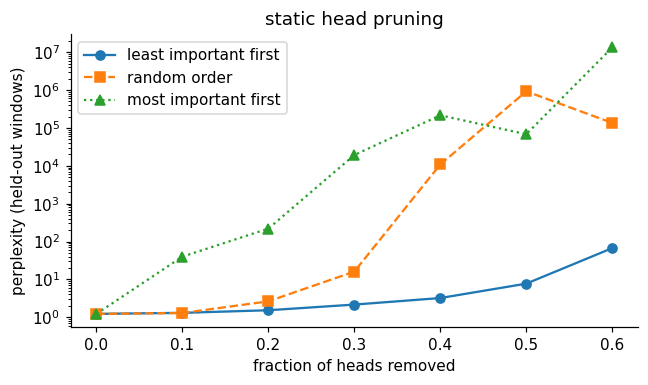

In [ ]:
"""
Evaluate static attention-head pruning using previously measured head
importance scores.

This script:
- Sorts all attention heads from least to most important according to their
  measured NLL impact.
- Builds layer-by-head masks that remove a selected fraction of heads.
- Evaluates held-out perplexity after applying each head-pruning mask.
- Compares three pruning strategies:
  - Removing the least important heads first.
  - Removing heads in a random order.
  - Removing the most important heads first.
- Evaluates several pruning fractions ranging from 0% to 60% of all heads.
- Averages three independently generated random pruning orders for each
  pruning fraction.
- Prints the resulting held-out perplexities for all three strategies.
- Plots perplexity against the fraction of removed heads on a logarithmic
  scale.

The experiment uses the head-importance measurements computed previously
from leave-one-head-out ablation. The held-out windows are kept separate from
the calibration windows used to estimate those importance scores.
"""

order_imp = imp.flatten().argsort()                      # least important first
def mask_from_order(order, frac):
    m = torch.ones(LQ * HQ); m[order[: int(frac * LQ * HQ)]] = 0; return m.view(LQ, HQ)
def ppl_with_mask(m):
    HM["mask"] = m; v = math.exp(nll_batch(qwen, B_ev)); HM["mask"] = None; return v

fracs = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
p_least = [ppl_with_mask(mask_from_order(order_imp, f)) for f in fracs]                       # remove least important first
p_most  = [ppl_with_mask(mask_from_order(order_imp.flip(0), f)) for f in fracs]              # remove most important first (worst case)
g = torch.Generator().manual_seed(0)
p_rand = [np.mean([ppl_with_mask(mask_from_order(torch.randperm(LQ * HQ, generator=g), f)) for _ in range(3)]) for f in fracs]

print(f"{'heads removed':>14}{'least-important-first':>23}{'random':>10}{'most-important-first':>22}")
for f, a, b, c in zip(fracs, p_least, p_rand, p_most): print(f"{f:>14.0%}{a:>23.2f}{b:>10.2f}{c:>22.2f}")
plt.figure(figsize=(6, 3.6)); plt.plot(fracs, p_least, "o-", label="least important first"); plt.plot(fracs, p_rand, "s--", label="random order"); plt.plot(fracs, p_most, "^:", label="most important first")
plt.yscale("log"); plt.xlabel("fraction of heads removed"); plt.ylabel("perplexity (held-out windows)"); plt.legend(); plt.title("static head pruning"); plt.tight_layout(); plt.show()

  tau  head-slots kept  perplexity
 0.00           100.0%        1.23
 0.25            97.1%        1.23
 0.50            82.6%        1.23
 0.75            62.1%        1.24
 1.00            47.0%        3.01
 1.25            26.9%       26.27
 1.50            19.7%   275891.88


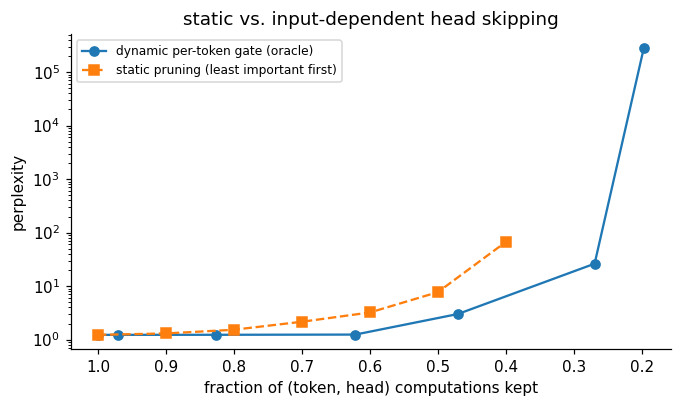

In [ ]:
"""
Compare static head pruning with input-dependent head gating.

This script:
- Defines a set of activation-norm thresholds for dynamic head selection.
- Applies an input-dependent gate independently for each token, layer, and
  attention head.
- Keeps a head when its output activation norm is at least the selected
  threshold multiplied by the mean head norm for that token.
- Measures the fraction of token-head computation slots retained by each
  threshold.
- Measures held-out perplexity for every dynamic gating threshold.
- Constructs corresponding retention fractions for the previously evaluated
  static least-important-first pruning strategy.
- Prints the retained computation fraction and perplexity for each dynamic
  threshold.
- Plots perplexity against the fraction of token-head computations retained,
  comparing dynamic input-dependent gating with static head pruning.
- Inverts the horizontal axis so that more aggressive computation reduction
  appears toward the left side of the plot.
- Removes the previously installed head hooks and resets the head-masking and
  dynamic-gating state after the experiment.

The dynamic gate is input-dependent because the decision to keep a head can
change for every token rather than permanently removing the same heads for
the entire input.
"""

# input-dependent gate: per token and layer, keep a head only if its output norm >= tau * (mean norm over heads for that token)
taus = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]; dyn = []
for tau in taus:
    HM.update(tau=tau, kept=0.0, n=0); v = math.exp(nll_batch(qwen, B_ev)); dyn.append((HM["kept"] / max(HM["n"], 1), v)); HM["tau"] = None
stat = [(1 - f, p) for f, p in zip(fracs, p_least)]
print(f"{'tau':>5}{'head-slots kept':>17}{'perplexity':>12}")
for tau, (kf, v) in zip(taus, dyn): print(f"{tau:>5.2f}{kf:>17.1%}{v:>12.2f}")
plt.figure(figsize=(6.3, 3.8))
plt.plot([k for k, _ in dyn], [v for _, v in dyn], "o-", label="dynamic per-token gate (oracle)"); plt.plot([k for k, _ in stat], [p for _, p in stat], "s--", label="static pruning (least important first)")
plt.yscale("log"); plt.xlabel("fraction of (token, head) computations kept"); plt.ylabel("perplexity"); plt.gca().invert_xaxis(); plt.legend(fontsize=8)
plt.title("static vs. input-dependent head skipping"); plt.tight_layout(); plt.show()
del _hooks; HM.update(mask=None, tau=None)

**Observations:** (1) a small set of critical heads and a long tail that can be removed almost for free; (2) whether the *per-token* gate keeps quality at a lower kept-fraction than static pruning i.e. whether **which heads matter depends on the input**. Caveat: our gate uses the head's output norm, which is only known *after* computing the head, so this is an **oracle upper bound**; a real system needs a cheap router that predicts the gate (as in mixture-of-heads / dynamic-head models).

In [ ]:
"""
Release the Qwen2.5-0.5B model and clear unused memory.

This cleanup removes the model reference and invokes the previously defined
memory-management helper to trigger garbage collection and release cached
CUDA memory when a GPU is being used.
"""

del qwen; free()

## 5) Summary

| Theme | Experiment Evidence |
|---|---|
| RoPE encodes only relative position | perplexity unchanged under position offsets up to 30 000 for Qwen (RoPE), collapses for GPT-2; low-frequency RoPE pairs are effectively position-free |
| Real attention is concentrated → sparsity is viable | keys needed for 90 % mass vs. position, entropy per layer and per head |
| Adaptive / learned sparsity | top-*p* gives each head a *different* number of keys; block-routing selects blocks with an O(n/64) score |
| Heads specialise | per-head ablation heat-map, head pruning curve, oracle per-token head gating |